In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

from retail_data import generate_retail_dataset

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

In [2]:
# 1. Load Retail Dataset

df = generate_retail_dataset(n_samples=2000, random_state=RANDOM_STATE)
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['Customer_Segment'].value_counts())
df.head()

Shape: (2000, 11)

Target distribution:
Customer_Segment
Regular    831
Premium    719
VIP        230
Budget     220
Name: count, dtype: int64


,CustomerID,Age,Annual_Income,Spending_Score,Region,Product_Category,Purchase_Channel,Num_Purchases,Avg_Transaction_Value,Total_Sales,Customer_Segment
0,1,22,107813,32,East,Furniture,In-Store,13,489.18,6663.34,Premium
1,2,58,26206,84,West,Clothing,Online,19,45.83,996.14,Regular
2,3,52,59752,4,East,Sports,In-Store,16,83.28,1471.70,Budget
3,4,40,65826,45,East,Electronics,Online,20,417.10,9209.14,Regular
4,5,40,99787,80,South,Groceries,Online,18,81.11,1467.51,VIP


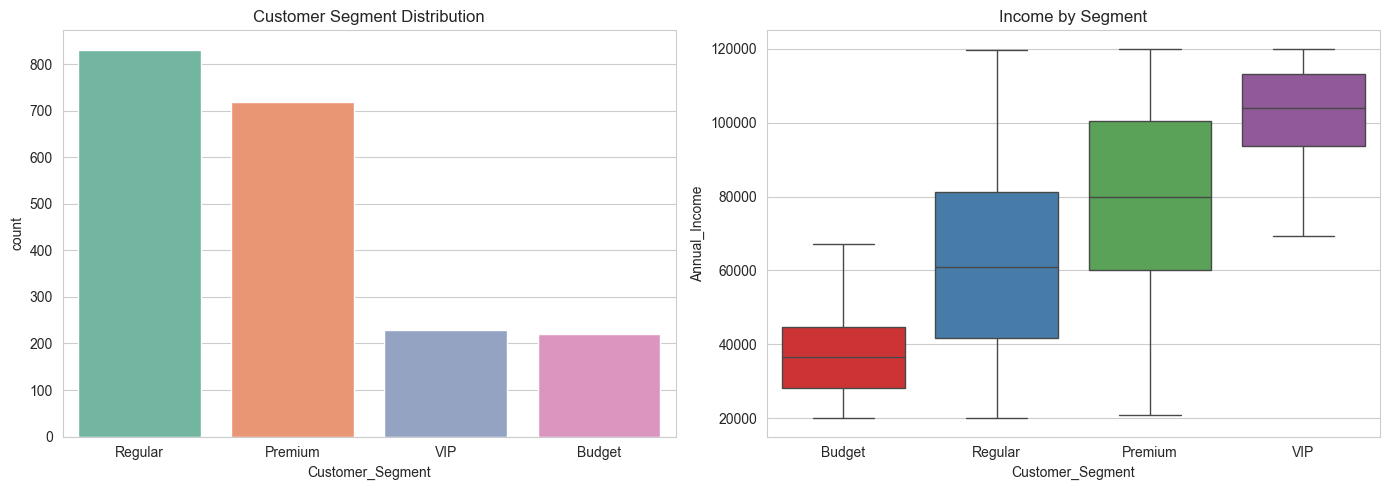

In [3]:
# 2. Exploratory Data Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Customer_Segment', order=df['Customer_Segment'].value_counts().index, ax=axes[0], palette='Set2')
axes[0].set_title('Customer Segment Distribution')

sns.boxplot(data=df, x='Customer_Segment', y='Annual_Income', order=['Budget', 'Regular', 'Premium', 'VIP'], ax=axes[1], palette='Set1')
axes[1].set_title('Income by Segment')
plt.tight_layout()
plt.show()

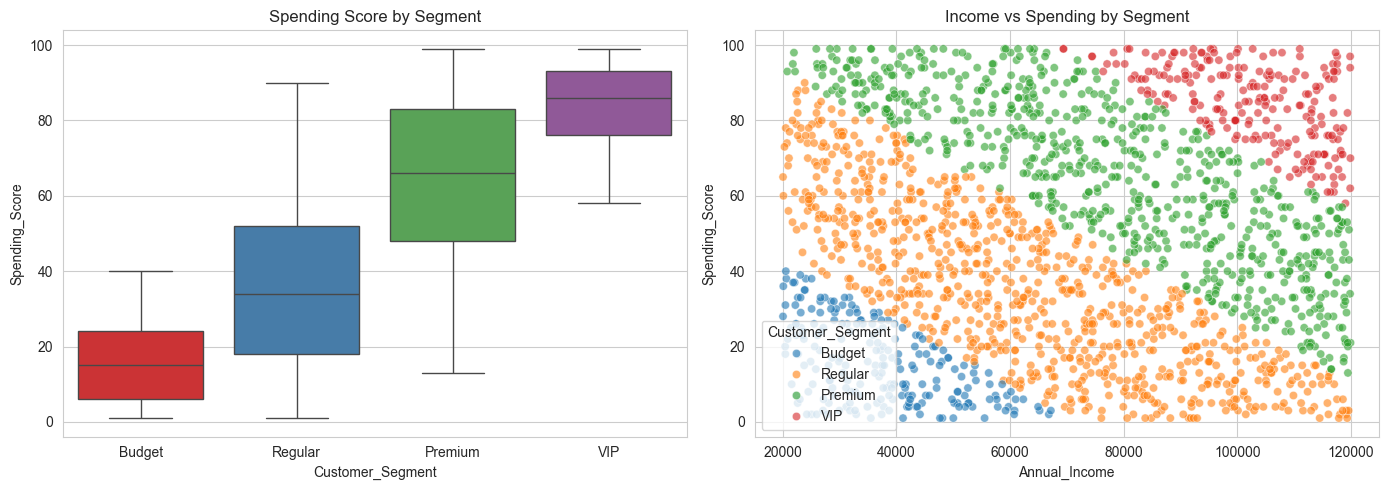

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Customer_Segment', y='Spending_Score', order=['Budget', 'Regular', 'Premium', 'VIP'], ax=axes[0], palette='Set1')
axes[0].set_title('Spending Score by Segment')
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Customer_Segment', hue_order=['Budget', 'Regular', 'Premium', 'VIP'], ax=axes[1], alpha=0.6)
axes[1].set_title('Income vs Spending by Segment')
plt.tight_layout()
plt.show()

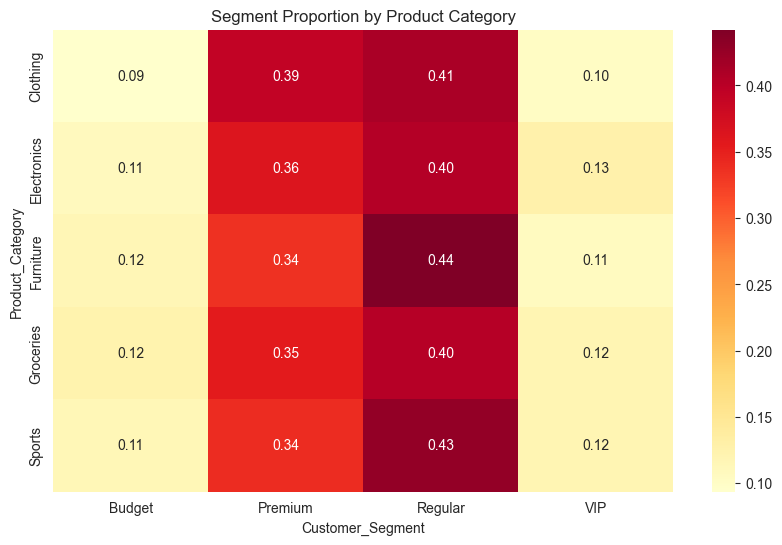

In [5]:
segment_by_cat = pd.crosstab(df['Product_Category'], df['Customer_Segment'], normalize='index')
sns.heatmap(segment_by_cat, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Segment Proportion by Product Category')
plt.show()

In [6]:
# 3. Feature Engineering & Train/Test Split

num_features = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value', 'Total_Sales']
cat_features = ['Region', 'Product_Category', 'Purchase_Channel']
target = 'Customer_Segment'

X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'\nTrain segment distribution:')
print(y_train.value_counts())

Train: 1600, Test: 400

Train segment distribution:
Customer_Segment
Regular    665
Premium    575
VIP        184
Budget     176
Name: count, dtype: int64


In [7]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])
     

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best params: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 15, 'classifier__weights': 'uniform'}
Best CV F1 (weighted): 0.7867


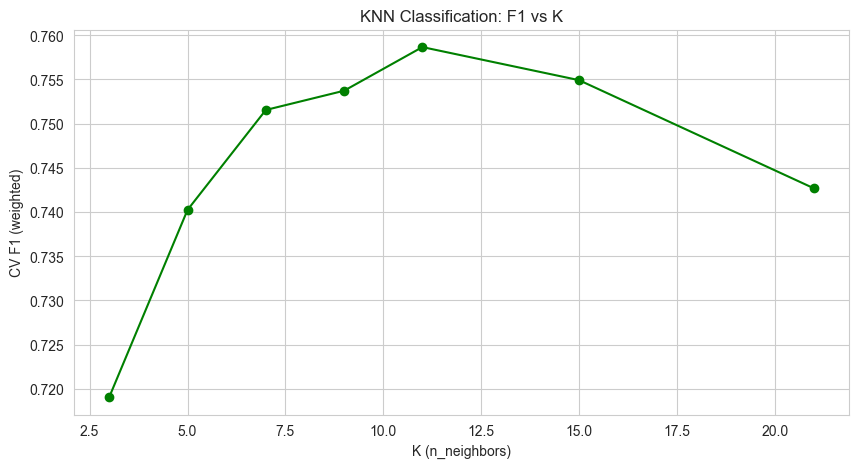

In [8]:
# 4. Hyperparameter Tuning

param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    knn_pipeline, param_grid, cv=5,
    scoring='f1_weighted',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV F1 (weighted): {grid_search.best_score_:.4f}')
     

results = pd.DataFrame(grid_search.cv_results_)
k_results = results.groupby('param_classifier__n_neighbors')['mean_test_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(k_results['param_classifier__n_neighbors'], k_results['mean_test_score'], 'go-')
plt.xlabel('K (n_neighbors)')
plt.ylabel('CV F1 (weighted)')
plt.title('KNN Classification: F1 vs K')
plt.show()

In [9]:
# 5. Evaluate Best Model on Test Set

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print('=== Test Set Performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred, average="weighted"):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred, average="weighted"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

=== Test Set Performance ===
Accuracy:  0.8300
Precision: 0.8408
Recall:    0.8300
F1 Score:  0.8230

Classification Report:
              precision    recall  f1-score   support

      Budget       0.85      0.50      0.63        44
     Premium       0.84      0.87      0.86       144
     Regular       0.79      0.94      0.86       166
         VIP       1.00      0.63      0.77        46

    accuracy                           0.83       400
   macro avg       0.87      0.73      0.78       400
weighted avg       0.84      0.83      0.82       400



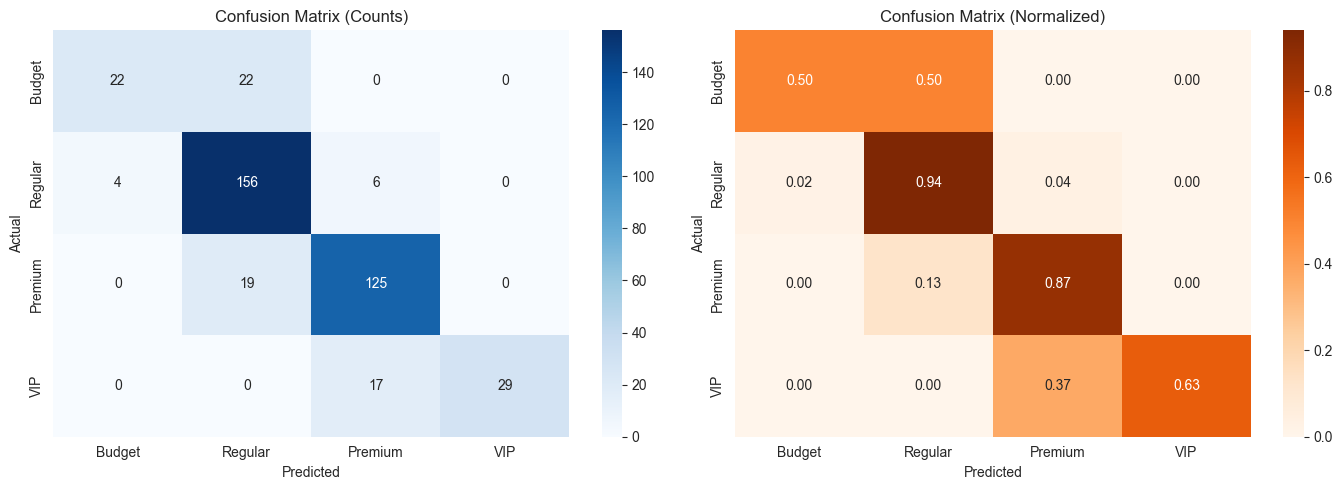

In [10]:
# 6. Confusion Matrix

labels = ['Budget', 'Regular', 'Premium', 'VIP']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual'); axes[0].set_title('Confusion Matrix (Counts)')

cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual'); axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.show()

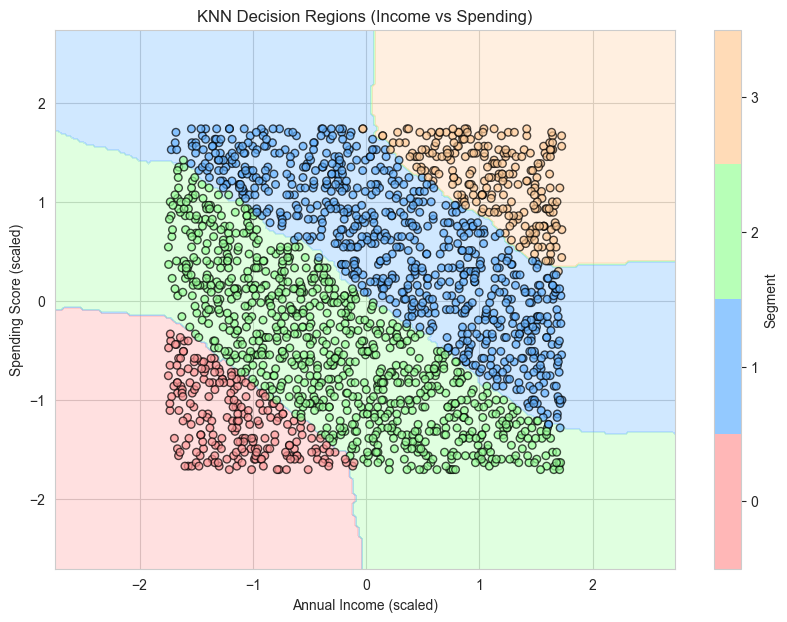

In [11]:
# 7. Decision Boundary (2D Projection)

from matplotlib.colors import ListedColormap

X_2d = df[['Annual_Income', 'Spending_Score']].values
y_2d = LabelEncoder().fit_transform(df['Customer_Segment'])
class_names = ['Budget', 'Regular', 'Premium', 'VIP']

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

knn_2d = KNeighborsClassifier(n_neighbors=best_model.named_steps['classifier'].n_neighbors,
                               weights=best_model.named_steps['classifier'].weights)
knn_2d.fit(X_2d_scaled, y_2d)

x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']))
scatter = plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap=ListedColormap(['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']), edgecolors='k', s=30, alpha=0.7)
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('KNN Decision Regions (Income vs Spending)')
plt.colorbar(scatter, ticks=[0, 1, 2, 3], label='Segment')
plt.clim(-0.5, 3.5)
plt.show()

In [12]:
# 8. Cross-Validation

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'CV Accuracy scores: {cv_scores.round(4)}')
print(f'Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
     

CV Accuracy scores: [0.795  0.8175 0.8025 0.805  0.815 ]
Mean CV Accuracy: 0.8070 (+/- 0.0083)


In [13]:
# 9. Classify New Customers

new_customers = pd.DataFrame({
    'Age': [22, 48, 35, 60],
    'Annual_Income': [25000, 110000, 65000, 90000],
    'Spending_Score': [80, 25, 55, 90],
    'Num_Purchases': [25, 5, 12, 30],
    'Avg_Transaction_Value': [30.0, 200.0, 75.0, 150.0],
    'Total_Sales': [750.0, 1000.0, 900.0, 4500.0],
    'Region': ['South', 'West', 'East', 'North'],
    'Product_Category': ['Clothing', 'Electronics', 'Groceries', 'Furniture'],
    'Purchase_Channel': ['Mobile', 'Online', 'In-Store', 'Online']
})

new_customers['Predicted_Segment'] = best_model.predict(new_customers)
new_customers['Confidence'] = best_model.predict_proba(new_customers).max(axis=1).round(3)
new_customers
     

,Age,Annual_Income,Spending_Score,Num_Purchases,Avg_Transaction_Value,Total_Sales,Region,Product_Category,Purchase_Channel,Predicted_Segment,Confidence
0,22,25000,80,25,30.0,750.0,South,Clothing,Mobile,Regular,0.533
1,48,110000,25,5,200.0,1000.0,West,Electronics,Online,Premium,0.533
2,35,65000,55,12,75.0,900.0,East,Groceries,In-Store,Premium,0.600
3,60,90000,90,30,150.0,4500.0,North,Furniture,Online,Premium,0.533
